In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler ,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [7]:
#READ THE CSV FILE#

data = pd.read_csv('churn_data.csv')

In [8]:
data.head()

,satisfaction,evaluation,number_of_projects,average_montly_hours,time_spend_company,work_accident,churn,promotion,department,salary
0,0.38,530.0,two,157.0,3+,no,yes,no,sales,low
1,0.80,860.0,five,262.0,6+,no,yes,no,sales,medium
2,0.11,880.0,seven,272.0,4+,no,yes,no,sales,medium
3,0.72,870.0,five,223.0,5+,no,yes,no,sales,low
4,0.37,520.0,two,159.0,3+,no,yes,no,sales,low


In [9]:
data.shape

(14999, 10)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   satisfaction          14990 non-null  float64
 1   evaluation            14936 non-null  float64
 2   number_of_projects    14955 non-null  object 
 3   average_montly_hours  14973 non-null  float64
 4   time_spend_company    14999 non-null  object 
 5   work_accident         14999 non-null  object 
 6   churn                 14999 non-null  object 
 7   promotion             14999 non-null  object 
 8   department            14958 non-null  object 
 9   salary                14999 non-null  object 
dtypes: float64(3), object(7)
memory usage: 1.1+ MB


In [11]:
data.isnull().sum()

,0
satisfaction,9
evaluation,63
number_of_projects,44
average_montly_hours,26
time_spend_company,0
work_accident,0
churn,0
promotion,0
department,41
salary,0


In [12]:
print(f"Duplicates before drop: {data.duplicated().sum()}")

Duplicates before drop: 2966


In [13]:
data = data.drop_duplicates()

In [14]:
print(f"Duplicates after drop: {data.duplicated().sum()}")

Duplicates after drop: 0


In [15]:
data.shape

(12033, 10)

In [16]:
num_df = data.select_dtypes(include="number")
cat_df = data.select_dtypes(include="object")

print(f"Numerical columns: {num_df.columns.tolist()}")
print(f"Categorical columns: {cat_df.columns.tolist()}")

Numerical columns: ['satisfaction', 'evaluation', 'average_montly_hours']
Categorical columns: ['number_of_projects', 'time_spend_company', 'work_accident', 'churn', 'promotion', 'department', 'salary']


In [17]:
for col in num_df.columns:
  num_df[col] = num_df[col].fillna(num_df[col].mean())

for col in cat_df.columns:
  cat_df[col] = cat_df[col].fillna(cat_df[col].mode()[0])

# Update the original 'data' DataFrame with the cleaned numerical and categorical values
data[num_df.columns] = num_df
data[cat_df.columns] = cat_df

print(f"Missing values after filling")
print(num_df.isna().sum())
print(cat_df.isna().sum())
print(data.isna().sum())

Missing values after filling
satisfaction            0
evaluation              0
average_montly_hours    0
dtype: int64
number_of_projects    0
time_spend_company    0
work_accident         0
churn                 0
promotion             0
department            0
salary                0
dtype: int64
satisfaction            0
evaluation              0
number_of_projects      0
average_montly_hours    0
time_spend_company      0
work_accident           0
churn                   0
promotion               0
department              0
salary                  0
dtype: int64


In [18]:
#Categorical variables were converted into numerical form using Label Encoding.
label_encoder=LabelEncoder()
for col in cat_df:
  cat_df[col]=label_encoder.fit_transform(cat_df[col])
cat_df.head()

,number_of_projects,time_spend_company,work_accident,churn,promotion,department,salary
0,5,2,0,1,0,7,1
1,0,5,0,1,0,7,2
2,2,3,0,1,0,7,2
3,0,4,0,1,0,7,1
4,5,2,0,1,0,7,1


In [19]:
data.dtypes

,0
satisfaction,float64
evaluation,float64
number_of_projects,object
average_montly_hours,float64
time_spend_company,object
work_accident,object
churn,object
promotion,object
department,object
salary,object


In [20]:
data=pd.concat([num_df,cat_df],axis=1)
data.head()

,satisfaction,evaluation,average_montly_hours,number_of_projects,time_spend_company,work_accident,churn,promotion,department,salary
0,0.38,530.0,157.0,5,2,0,1,0,7,1
1,0.80,860.0,262.0,0,5,0,1,0,7,2
2,0.11,880.0,272.0,2,3,0,1,0,7,2
3,0.72,870.0,223.0,0,4,0,1,0,7,1
4,0.37,520.0,159.0,5,2,0,1,0,7,1


In [21]:
X = data.drop("churn", axis=1)
y = data["churn"]


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
#Numerical features were standardized using StandardScaler.

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

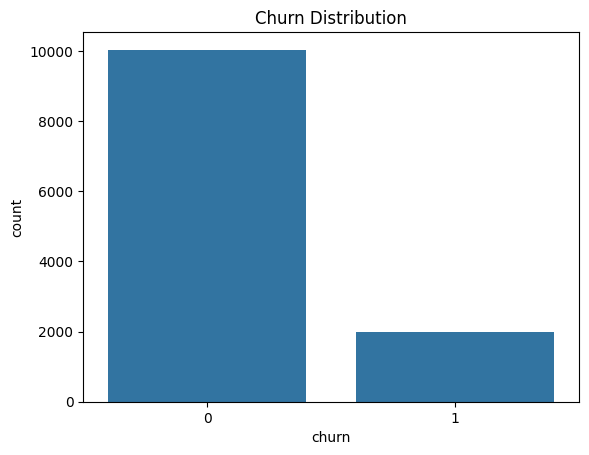

In [24]:
sns.countplot(x=y)
plt.title("Churn Distribution")
plt.show()

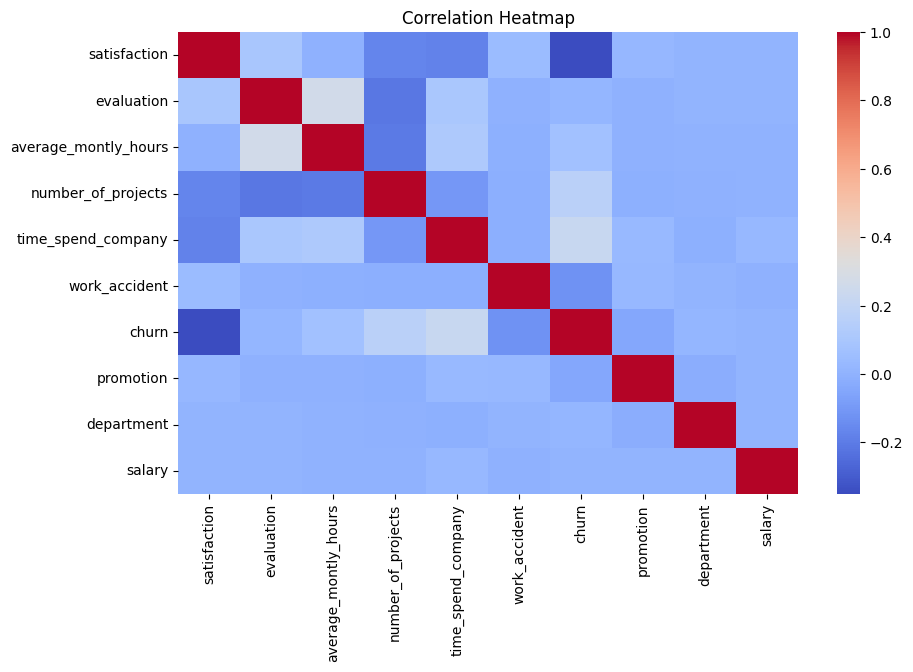

In [25]:
#EDA shows the class balance of churn and correlations between features.

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [26]:
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)


In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {"n_estimators": [100, 200],"max_depth": [None, 10, 20]}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_


In [28]:
models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

results = []

for name, pred in models.items():
    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.841712,0.553571,0.233083,0.328042
1,Decision Tree,0.968010,0.890777,0.919799,0.905055
2,Random Forest,0.987121,0.991979,0.929825,0.959897


In [29]:
best_model.predict(X_test[:5])


array([0, 0, 0, 1, 0])